In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, ttest_ind
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score

In [38]:
df = pd.read_csv('../data/processed/investments_VC_cleaned.csv')
df

,permalink,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,...,secondary_market,product_crowdfunding,round_a,round_b,round_c,round_d,round_e,round_f,round_g,round_h
0,/organization/waywire,#waywire,http://www.waywire.com,Entertainment|Politics|Social Media|News,News,1750000.00,acquired,USA,NY,New York City,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,/organization/tv-communications,&TV Communications,http://enjoyandtv.com,Games,Games,4000000.00,operating,USA,CA,Los Angeles,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,/organization/rock-your-paper,'Rock' Your Paper,http://www.rockyourpaper.org,Publishing|Education,Publishing,40000.00,operating,EST,Unknown,Tallinn,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,/organization/in-touch-network,(In)Touch Network,http://www.InTouchNetwork.com,Electronics|Guides|Coffee|Restaurants|Music|Ip...,Electronics,1500000.00,operating,GBR,MA,London,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,/organization/r-ranch-and-mine,-R- Ranch and Mine,Unknown,Tourism|Entertainment|Games,Tourism,60000.00,operating,USA,TX,Dallas,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49431,/organization/zzish,Zzish,http://www.zzish.com,Analytics|Gamification|Developer Apis|Ios|Andr...,Education,320000.00,operating,GBR,MA,London,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
49432,/organization/zznode-science-and-technology-co...,ZZNode Science and Technology,http://www.zznode.com,Enterprise Software,Enterprise Software,1587301.00,operating,CHN,Unknown,Beijing,...,0.0,0.0,1587301.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
49433,/organization/zzzzapp-com,Zzzzapp Wireless ltd.,http://www.zzzzapp.com,Web Development|Advertising|Wireless|Mobile,Web Development,97398.00,operating,HRV,Unknown,Split,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
49434,/organization/a-list-games,[a]list games,http://www.alistgames.com,Games,Games,9300000.00,operating,Unknown,Unknown,Unknown,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [39]:
df_known = df[df['status'] != 'unknown'].copy()
df_known['is_success'] = df_known['status'].isin(['operating', 'acquired']).astype(int)
print('Analysis dataset: ' + str(df_known.shape))

Analysis dataset: (49436, 40)


In [40]:
# H0: No relationship between market sector and startup status
# H1: Market sector significantly predicts startup status

top_markets = df_known['market'].value_counts().head(15).index
df_chi = df_known[df_known['market'].isin(top_markets)]

In [41]:
contingency = pd.crosstab(df_chi['market'], df_chi['status'])
chi2, p_value, dof, expected = chi2_contingency(contingency)

print('CHI-SQUARED: SECTOR vs STATUS')
print('Chi2: ' + str(round(chi2,4)) + '  |  dof: ' + str(dof) + '  |  p-value: ' + str(round(p_value,6)))
print()
if p_value < 0.05:
    print('REJECT H0: Sector is a statistically significant predictor.')
    print('VC fund SHOULD adjust allocation by sector.')
else:
    print('FAIL TO REJECT H0.')

CHI-SQUARED: SECTOR vs STATUS
Chi2: 1044.0373  |  dof: 28  |  p-value: 0.0

REJECT H0: Sector is a statistically significant predictor.
VC fund SHOULD adjust allocation by sector.


In [42]:
# H0: Successful and failed startups raise the same amount
# H1: Successful startups raise significantly more

success_f = df_known[df_known['is_success']==1]['funding_total_usd'].dropna()
failure_f = df_known[df_known['is_success']==0]['funding_total_usd'].dropna()

# Remove extreme outliers (top 1%)
success_f = success_f[success_f < success_f.quantile(0.99)]
failure_f = failure_f[failure_f < failure_f.quantile(0.99)]

t_stat, p_val = ttest_ind(success_f, failure_f, equal_var=False)

print('T-TEST: FUNDING vs STATUS')
print('Successful mean: $' + str(round(success_f.mean())))
print('Failed mean:     $' + str(round(failure_f.mean())))
print('T-stat: ' + str(round(t_stat,4)) + '  |  p-value: ' + str(round(p_val,6)))
if p_val < 0.05:
    print('REJECT H0: Successful startups raise significantly more.')

T-TEST: FUNDING vs STATUS
Successful mean: $2840501
Failed mean:     $2295948
T-stat: 7.6959  |  p-value: 0.0
REJECT H0: Successful startups raise significantly more.


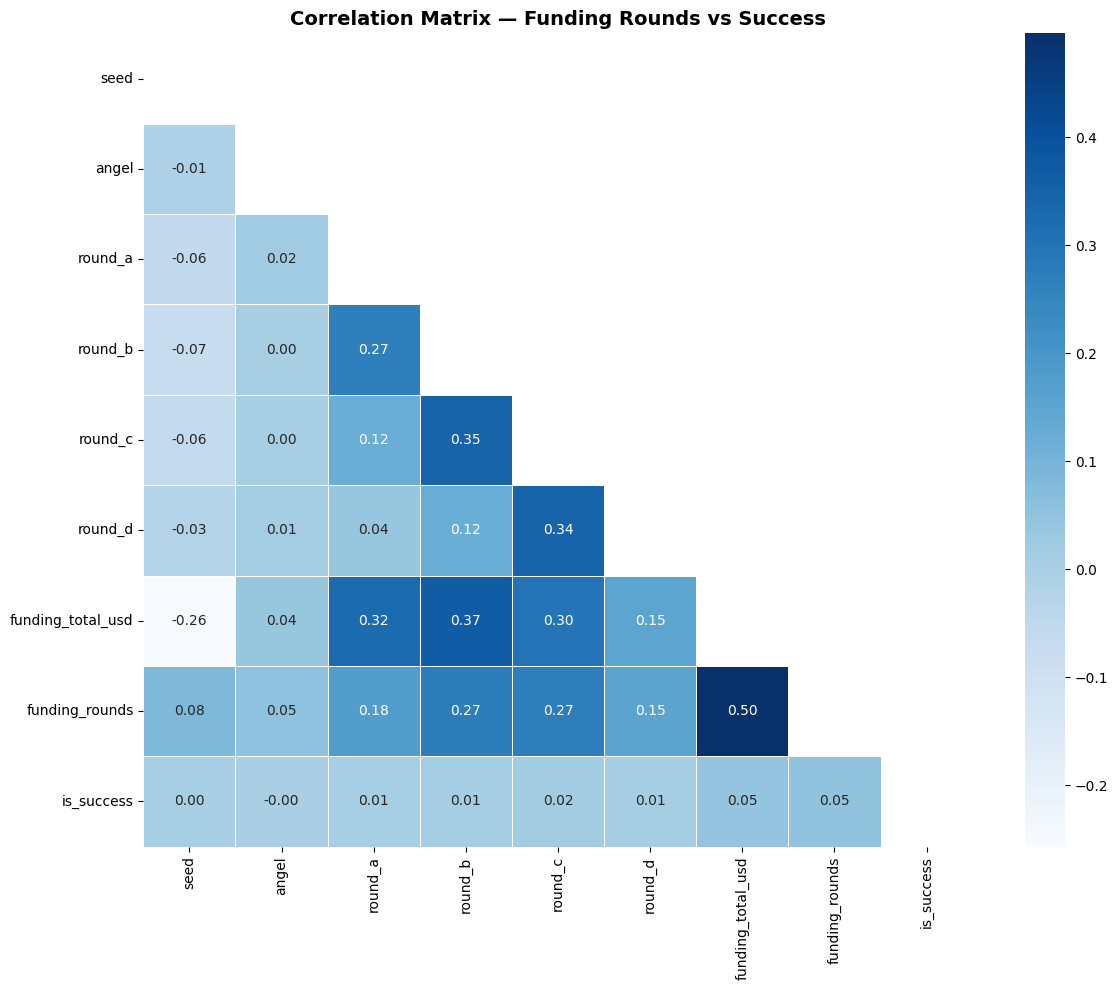

Correlation with is_success:
is_success           1.000000
funding_rounds       0.051596
funding_total_usd    0.046065
round_c              0.016132
round_d              0.010895
round_b              0.008774
round_a              0.007670
seed                 0.004697
angel               -0.002816
Name: is_success, dtype: float64


In [43]:
round_cols = ['seed','angel','round_a','round_b','round_c',
              'round_d','funding_total_usd','funding_rounds','is_success']

corr_df = df_known[round_cols].dropna()
corr_matrix = corr_df.corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='Blues',
            mask=mask, ax=ax, linewidths=0.5)
ax.set_title('Correlation Matrix — Funding Rounds vs Success', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/stats_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

print('Correlation with is_success:')
print(corr_matrix['is_success'].sort_values(ascending=False))

In [44]:
features = ['funding_total_usd','funding_rounds','seed','venture',
            'round_a','round_b']

df_model = df_known[features + ['is_success']].dropna()
X = df_model[features]
y = df_model['is_success']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
model.fit(X_train_sc, y_train)
y_pred = model.predict(X_test_sc)

print('Accuracy: ' + str(round(accuracy_score(y_test, y_pred), 3)))
print(classification_report(y_test, y_pred, zero_division=0))

coef_df = pd.DataFrame({'Feature': features, 'Coefficient': model.coef_[0]})
print(coef_df.sort_values('Coefficient', ascending=False).to_string())
print('Positive coefficients increase success probability.')

Accuracy: 0.412
              precision    recall  f1-score   support

           0       0.06      0.72      0.11       521
           1       0.96      0.39      0.56      9367

    accuracy                           0.41      9888
   macro avg       0.51      0.56      0.34      9888
weighted avg       0.92      0.41      0.54      9888

             Feature  Coefficient
0  funding_total_usd     0.602461
1     funding_rounds     0.242598
2               seed     0.047191
4            round_a    -0.007587
5            round_b    -0.064658
3            venture    -0.471568
Positive coefficients increase success probability.


In [45]:
print(df_known.columns)

Index(['permalink', 'name', 'homepage_url', 'category_list', 'market',
       'funding_total_usd', 'status', 'country_code', 'state_code', 'region',
       'city', 'funding_rounds', 'founded_at', 'founded_month',
       'founded_quarter', 'founded_year', 'first_funding_at',
       'last_funding_at', 'seed', 'venture', 'equity_crowdfunding',
       'undisclosed', 'convertible_note', 'debt_financing', 'angel', 'grant',
       'private_equity', 'post_ipo_equity', 'post_ipo_debt',
       'secondary_market', 'product_crowdfunding', 'round_a', 'round_b',
       'round_c', 'round_d', 'round_e', 'round_f', 'round_g', 'round_h',
       'is_success'],
      dtype='object')
